# Optimal Model

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import math

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
from mlxtend.evaluate import GroupTimeSeriesSplit
from mlxtend.evaluate.time_series import plot_splits
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf
from tensorflow.keras.layers import MaxPooling1D
import datetime

%load_ext tensorboard


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [65]:
# GPU Availability Check
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.experimental.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

# List all physical devices
physical_devices = tf.config.list_physical_devices()
print("\n📱 All Physical Devices:")
for device in physical_devices:
    print(f"  {device}")

# Check if TensorFlow is built with CUDA support
print(f"\n🔧 CUDA Support: {tf.test.is_built_with_cuda()}")

# Prevent TensorFlow from allocating all GPU memory at once
if gpus:
    try:
        # Enable memory growth for each GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(f"❌ Error setting memory growth: {e}")
        
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

TensorFlow version: 2.20.0
Num GPUs Available: 1

📱 All Physical Devices:
  PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

🔧 CUDA Support: True
❌ Error setting memory growth: Physical devices cannot be modified after being initialized


In [66]:
def set_reproducible(seed=12345):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

In [67]:
dps1200 = pd.read_csv("../../data/dps1200.csv")
dps1200 = dps1200.sort_values("year", ascending=True)
dps1200 = dps1200[dps1200["year"] >= 1800]
print(dps1200.shape)
dps1200.head()

(575, 414)


,year,tree,Origin,type,X2970,X2968,X2966,X2964,X2962,X2960,...,X818,X816,X814,X812,X810,X808,X806,X804,X802,X800
821,1800,JMS7a,FIN,living,0.021011,0.021199,0.021412,0.021632,0.021853,0.022087,...,-0.025427,-0.025378,-0.025341,-0.025321,-0.025318,-0.025326,-0.025347,-0.025387,-0.025442,-0.025503
1192,1801,SZLPS08a,AUT,living,0.016859,0.017079,0.017309,0.017557,0.017827,0.018115,...,-0.018325,-0.018201,-0.018095,-0.018010,-0.017949,-0.017914,-0.017908,-0.017935,-0.017990,-0.018064
947,1801,LUO8a,FIN,living,0.020787,0.021227,0.021688,0.022151,0.022604,0.023049,...,-0.022127,-0.022025,-0.021931,-0.021851,-0.021795,-0.021769,-0.021770,-0.021796,-0.021841,-0.021903
394,1801,Bre029,NOR,water,0.019230,0.019520,0.019827,0.020153,0.020490,0.020822,...,-0.021681,-0.021514,-0.021360,-0.021229,-0.021131,-0.021068,-0.021037,-0.021038,-0.021070,-0.021125
268,1802,BHNPS193a,AUT,constr,0.017848,0.018055,0.018265,0.018482,0.018713,0.018962,...,-0.018974,-0.018840,-0.018722,-0.018627,-0.018559,-0.018519,-0.018508,-0.018525,-0.018568,-0.018631


In [68]:
dpa = pd.read_csv("../../data/dpa.csv")
dpa = dpa.sort_values("year", ascending=True)
dpa = dpa[dpa["year"] >= 1800]
print(dpa.shape)
dpa.head()

(327, 414)


,year,origin,Jahr,X3996,X2970,X2968,X2966,X2964,X2962,X2960,...,X818,X816,X814,X812,X810,X808,X806,X804,X802,X800
521,1800,DST,1800,0.010303,0.017534,0.017898,0.018272,0.018653,0.019039,0.019431,...,-0.020985,-0.020822,-0.020683,-0.020574,-0.020504,-0.020474,-0.020486,-0.020540,-0.020633,-0.020758
1498,1800,WIE,1800,0.016896,0.017539,0.017709,0.017885,0.018058,0.018231,0.018422,...,-0.023917,-0.023788,-0.023676,-0.023586,-0.023522,-0.023489,-0.023486,-0.023509,-0.023560,-0.023635
658,1800,SWS,1800,0.011154,0.018527,0.018810,0.019103,0.019405,0.019715,0.020033,...,-0.021223,-0.021109,-0.021012,-0.020936,-0.020887,-0.020866,-0.020876,-0.020915,-0.020980,-0.021068
419,1801,DST,1801,0.005733,0.015686,0.016034,0.016397,0.016774,0.017165,0.017569,...,-0.018596,-0.018426,-0.018277,-0.018157,-0.018072,-0.018027,-0.018022,-0.018057,-0.018129,-0.018234
373,1801,DST,1801,0.015178,0.018400,0.018671,0.018954,0.019247,0.019551,0.019866,...,-0.021866,-0.021789,-0.021727,-0.021685,-0.021666,-0.021674,-0.021708,-0.021769,-0.021855,-0.021962


In [69]:
daa = pd.read_csv("../../data/daa.csv")
daa = daa.sort_values("year", ascending=True)
daa = daa[daa["year"] >= 1800]
print(daa.shape)
daa.head()

(268, 414)


,year,origin,Jahr,X3996,X2970,X2968,X2966,X2964,X2962,X2960,...,X818,X816,X814,X812,X810,X808,X806,X804,X802,X800
407,1800,WFA,1800,0.008700,0.016876,0.017095,0.017325,0.017567,0.017819,0.018081,...,-0.019397,-0.019227,-0.019073,-0.018945,-0.018847,-0.018785,-0.018759,-0.018769,-0.018814,-0.018889
352,1800,WFA,1800,0.006262,0.017778,0.018066,0.018364,0.018669,0.018981,0.019303,...,-0.018022,-0.017905,-0.017807,-0.017732,-0.017685,-0.017670,-0.017686,-0.017733,-0.017808,-0.017908
448,1800,WFA,1800,0.008141,0.017552,0.017774,0.018003,0.018239,0.018483,0.018736,...,-0.019149,-0.019014,-0.018895,-0.018801,-0.018735,-0.018700,-0.018697,-0.018724,-0.018780,-0.018861
682,1800,WIE,1800,0.003135,0.012487,0.012566,0.012661,0.012760,0.012853,0.012950,...,-0.018802,-0.018652,-0.018516,-0.018399,-0.018305,-0.018237,-0.018200,-0.018192,-0.018209,-0.018241
684,1800,WIE,1800,0.009552,0.018023,0.018200,0.018379,0.018557,0.018730,0.018902,...,-0.020795,-0.020624,-0.020473,-0.020346,-0.020250,-0.020191,-0.020173,-0.020194,-0.020244,-0.020316


In [70]:
frames = [dps1200, dpa, daa]

result = pd.concat(frames)
result = result.sort_values("year", ascending=True)
result.head()

,year,tree,Origin,type,X2970,X2968,X2966,X2964,X2962,X2960,...,X812,X810,X808,X806,X804,X802,X800,origin,Jahr,X3996
821,1800,JMS7a,FIN,living,0.021011,0.021199,0.021412,0.021632,0.021853,0.022087,...,-0.025321,-0.025318,-0.025326,-0.025347,-0.025387,-0.025442,-0.025503,NaN,NaN,NaN
658,1800,NaN,NaN,NaN,0.018527,0.018810,0.019103,0.019405,0.019715,0.020033,...,-0.020936,-0.020887,-0.020866,-0.020876,-0.020915,-0.020980,-0.021068,SWS,1800.0,0.011154
407,1800,NaN,NaN,NaN,0.016876,0.017095,0.017325,0.017567,0.017819,0.018081,...,-0.018945,-0.018847,-0.018785,-0.018759,-0.018769,-0.018814,-0.018889,WFA,1800.0,0.008700
352,1800,NaN,NaN,NaN,0.017778,0.018066,0.018364,0.018669,0.018981,0.019303,...,-0.017732,-0.017685,-0.017670,-0.017686,-0.017733,-0.017808,-0.017908,WFA,1800.0,0.006262
448,1800,NaN,NaN,NaN,0.017552,0.017774,0.018003,0.018239,0.018483,0.018736,...,-0.018801,-0.018735,-0.018700,-0.018697,-0.018724,-0.018780,-0.018861,WFA,1800.0,0.008141


In [71]:
features = result.iloc[:, 4:414].values
labels = result.iloc[:, 0].values
print(features.shape)
print(features)
print(len(labels))

(1170, 410)
[[ 0.02101072  0.02119926  0.02141234 ... -0.02538711 -0.02544172
  -0.02550349]
 [ 0.01852676  0.01880977  0.01910263 ... -0.02091458 -0.02097984
  -0.02106828]
 [ 0.0168757   0.01709455  0.0173249  ... -0.01876938 -0.01881401
  -0.01888901]
 ...
 [ 0.01730234  0.01766088  0.01802742 ... -0.02047177 -0.02052959
  -0.02061209]
 [ 0.01901787  0.01929498  0.01958385 ... -0.02286812 -0.02294226
  -0.02303355]
 [ 0.02006235  0.02051521  0.02097618 ... -0.02179224 -0.02186356
  -0.02195737]]
1170


In [72]:
def convertToDecade(y:int) -> int: 
    return int(str(y)[:3])

def calculate_sample_weights(y_train):

    decades = [convertToDecade(year) for year in y_train]

    unique_decades, counts = np.unique(decades, return_counts=True)
    total_samples = len(y_train)
    
    weights = {}
    for decade, count in zip(unique_decades, counts):
        weights[decade] = 1 - count/total_samples

    sample_weights = []
    for year in y_train:
        sample_weights.append(weights[convertToDecade(year)])
        
    return np.array(sample_weights)            


First redifine the model into a function where the hyperparameters are inputs. This function evaluates the model and ouptups a desired score/metric.

In [73]:
# Add learning rate scheduling callback
def create_lr_scheduler():
    # reduces LR when validation loss plateaus
    scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=80,
        min_lr=1e-6,
        verbose=1
    )
    return scheduler

In [74]:
def build_model_old(DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, input_dim):

    activation1='relu'
    activation2='linear'
    
    model = keras.Sequential()
    model.add(keras.layers.Input((input_dim, 1)))
    model.add(keras.layers.GaussianNoise(0.0001))

    model.add(keras.layers.Conv1D(C1_K, (C1_S), padding='valid', activation=activation1))
    model.add(keras.layers.Conv1D(C2_K, (C2_S), padding='valid', activation=activation1))
    model.add(keras.layers.Conv1D(C3_K, (C3_S), padding='valid', activation=activation1))
    model.add(MaxPooling1D(pool_size=2))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dropout(DropoutR))
    
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(1, activation=activation2))

    model.compile(loss=tf.keras.losses.Huber(), optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics=['mean_absolute_error'])
    
    return model


In [75]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, Add,
    MaxPooling1D, GlobalAveragePooling1D, Dense, Concatenate
)

def create_optimizer():
    # opt = keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-5)  # causes underfitting?
    opt = keras.optimizers.Adam(learning_rate=0.001)
    return opt

# best so far at loss around 3e-4
# praise be Gemini Pro 2.5, https://g.co/gemini/share/e3f26b1e78f3
def inception_residual_module(input_tensor, num_filters):
    """
    The core building block of the network. It processes data at multiple scales
    and includes a residual connection for stable training.
    """
    # Use a 1x1 convolution as a "bottleneck" to reduce computational cost
    bottleneck = Conv1D(filters=num_filters // 4, kernel_size=1, padding='same', use_bias=False)(input_tensor)
    bottleneck = BatchNormalization()(bottleneck)
    bottleneck = Activation('relu')(bottleneck)

    # --- Parallel branches for multi-scale feature extraction ---
    # Small kernel for sharp peaks
    branch1 = Conv1D(filters=num_filters // 4, kernel_size=3, padding='same', use_bias=False)(bottleneck)

    # Medium kernel for wider features
    branch2 = Conv1D(filters=num_filters // 2, kernel_size=7, padding='same', use_bias=False)(bottleneck)
    
    # Large kernel for broad shapes
    branch3 = Conv1D(filters=num_filters // 4, kernel_size=11, padding='same', use_bias=False)(bottleneck)

    # Combine the features from all branches
    concatenated = Concatenate()([branch1, branch2, branch3])
    
    # Final 1x1 convolution to restore the desired number of filters
    final_conv = Conv1D(filters=num_filters, kernel_size=1, padding='same', use_bias=False)(concatenated)
    final_conv = BatchNormalization()(final_conv)

    # --- Residual Connection ---
    # Add the original input to the output of the convoluted path.
    # This helps prevent vanishing gradients in a deep network.
    if input_tensor.shape[-1] != num_filters:
        shortcut = Conv1D(filters=num_filters, kernel_size=1, padding='same', use_bias=False)(input_tensor)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = input_tensor
        
    output = Add()([final_conv, shortcut])
    output = Activation('relu')(output)
    
    return output

def build_model(DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, input_dim):
    """
    Constructs the full Inception-Residual model.
    """

    inputs = Input(shape=(input_dim, 1))

    # --- Stem: Initial Feature Extraction ---
    # A standard convolution to process the raw input and reduce dimensionality.
    x = Conv1D(filters=64, kernel_size=13, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    # --- Core Blocks: Deep Feature Learning ---
    # Stack the custom modules to learn increasingly complex features.
    x = inception_residual_module(x, num_filters=128)
    x = inception_residual_module(x, num_filters=128)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    x = inception_residual_module(x, num_filters=256)
    x = inception_residual_module(x, num_filters=256)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    # --- Head: Final Prediction ---
    # Global Average Pooling is the key to fighting overfitting.
    # It creates one feature per filter, summarizing the entire spectrum.
    x = GlobalAveragePooling1D()(x)
    
    # A small dense head for the final regression output.
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='linear', name='age_output')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=create_optimizer(), metrics=['mean_absolute_error'])
    model.summary()

    return model

# Crossvalidation

Since NN training involves random sampling and weights initialization (in this case), it is usefull to use cross-validation.

In [76]:
def recalculate_year(years):
    # years = years * 1.0  # test
    # years = np.exp(years)
    # years = years * 100.0 + 1900
    years = years + 1800
    return years

In [77]:
def decalculate_year(years):
    # years = years / 1.0  # test
    # years = np.log(years)
    # years = (years - 1900) / 100.0
    years = years - 1800
    return years

In [78]:
## Compute error metrics
def error_metrices(y_true_train, y_predicted_train, y_true_test, y_predicted_test):
    y_true_train = recalculate_year(y_true_train)
    y_predicted_train = recalculate_year(y_predicted_train)
    y_true_test = recalculate_year(y_true_test)
    y_predicted_test = recalculate_year(y_predicted_test)

    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_predicted_train))
    rmse_test = np.sqrt(mean_squared_error(y_true_test, y_predicted_test))
    R2_train= r2_score(y_true_train, y_predicted_train)
    R2_test= r2_score(y_true_test, y_predicted_test)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true_train, y_predicted_train).numpy()
    hub_test = h(y_true_test, y_predicted_test).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    (Train/Test) = {R2_train:.3f} / {R2_test:.3f}")
    print(f"RMSE  (Train/Test) = {rmse_train:.3f} / {rmse_test:.3f}")
    print(f"Huber (Train/Test) = {hub_train:.3f} / {hub_test:.3f}")

    return (rmse_train, rmse_test, R2_train, R2_test, hub_train, hub_test)

class ModelWithData:
    def __init__(self, history, train_x, train_label, train_predicted, test_x, test_label, test_predicted, score:float, iteration, model) -> None:
        self.history = history
        self.train_x = train_x
        self.train_label = train_label
        self.train_predicted = train_predicted
        self.test_x = test_x
        self.test_label = test_label
        self.test_predicted = test_predicted
        self.score = score
        self.iteration = iteration
        self.model = model

    def isBetter(self, otherScore: float) -> bool:
        return otherScore < 0 or (self.score >= 0 and self.score <= otherScore)

In [79]:
def calculate_groups(years, years_in_group=100):
    groups = np.zeros(len(years))

    for i in range(len(years)):
        groups[i] = years[i] // years_in_group
    
    print("Groups:")
    print(groups)
    return groups

In [80]:
class HarmonizedTimeSplit:
    def __init__(self, validation_portion=0.1, random_seed=12345):
        self._validation_portion = validation_portion
        self._random_seed = random_seed
        self._random = random.Random(random_seed)

    def split(self, X, y = None, groups = None):

        if groups is None:
            raise ValueError("The groups should be specified")
        
        self._random = random.Random(self._random_seed)
        group_dict = self._calculate_group_indices(groups)
        train_indices = []
        test_indices = []

        for group_start, group_end in group_dict.values():
            group_indices = []

            for index in range(group_start, group_end):
                group_indices.append(index)
            
            self._random.shuffle(group_indices)

            validation_end = math.floor(len(group_indices)*self._validation_portion)

            if validation_end <= 0:
                train_indices.extend(group_indices)
            else:
                test_indices.extend(group_indices[:validation_end])
                train_indices.extend(group_indices[validation_end:])

        yield np.asarray(sorted(train_indices)), np.asarray(sorted(test_indices))

        
    def _calculate_group_indices(self, groups) -> dict[str, tuple[int,int]]:
        group_dict = {}
        current_group = None

        for index in range(len(groups)):
            group = str(groups[index])

            if group in group_dict:
                if group != current_group:
                    raise ValueError(f"The groups should be specified in consequtive order. Found group '{group}' again at index {index}")
            else:
                if current_group is not None:
                    (current_group_start, current_group_end) = group_dict[current_group]
                    group_dict[current_group] = (current_group_start, index)
                
                current_group = group
                group_dict[group] = (index, len(groups))

        return group_dict

    def plot_splits(self, groups):
        for train_indices, test_indices in self.split(None, None, groups):
            self._plot_split(train_indices, test_indices, groups)
    
    def _plot_split(self, train_indices, test_indices, groups):
        group_dict = self._calculate_group_indices(groups)

        train_in_group = np.zeros(len(group_dict))
        test_in_group = np.zeros(len(group_dict))
        groups = sorted(group_dict.keys())

        for group_index, group_name in enumerate(groups):
            (group_start, group_end) = group_dict[group_name]
            train_in_group[group_index] = self._count_in_group(train_indices, group_start, group_end)
            test_in_group[group_index] = self._count_in_group(test_indices, group_start, group_end)

        x_values = np.arange(len(groups))
        width = 0.33

        rects = plt.bar(x_values, train_in_group, width, color='k', label='Train')
        plt.bar_label(rects, padding=3)
        rects = plt.bar(x_values + width, test_in_group, width, color='r', label='Test')
        plt.bar_label(rects, padding=3)

        # Labels, legend, and title
        plt.xlabel('Groups')
        plt.xticks(x_values + width/2, groups)
        plt.ylabel('Sample Count')
        plt.legend()
        plt.title('Distribution of Train vs Test in Split')

        # Show the plot
        plt.show()
    
    def _count_in_group(self, indices, group_start, group_end):
        count = 0
        for train_index in indices:
            if train_index >= group_start and train_index < group_end:
                count += 1
            elif train_index >= group_end:
                break

        return count


Groups:
[18. 18. 18. ... 20. 20. 20.]


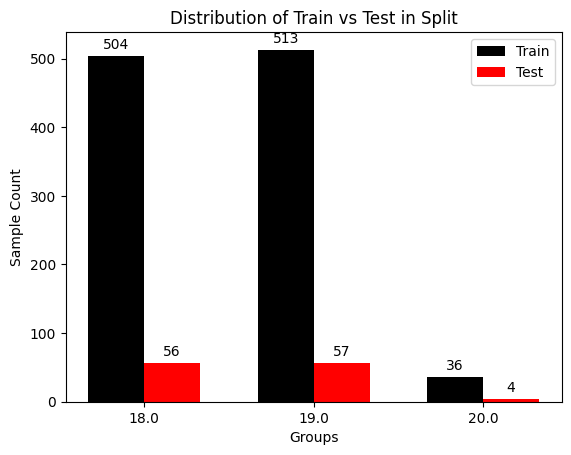

In [81]:
hts = HarmonizedTimeSplit(validation_portion=0.1)
y = np.array(labels)
groups = calculate_groups(y, 100)
hts.plot_splits(groups)

In [82]:

def evaluations_of_models(features, labels, DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, seed=12345, name="Anabell", epochs=100, years_in_group=100, validation_portion=0.01):    

    x = np.array(features)
    y_raw = np.array(labels)
    y = decalculate_year(y_raw)

    groups = calculate_groups(y, years_in_group)
    input_dim = 410
    
    # generate model
    model = build_model(DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, input_dim)

    # Define the number of folds for Cross-Validation
    hts = HarmonizedTimeSplit(validation_portion=validation_portion)
    hts.plot_splits(groups)

    scores_train = { "rmse": [], "r2": [], "huber": []}
    scores_test = { "rmse": [], "r2": [], "huber": []}

    bestMwd = ModelWithData(None, 0, 0, 0, 0, 0, 0, -1, 0, None)

    tensorboard_base_dir = "tensorboard_logs"
    time_string = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    all_mwds = []
    
    # Iterate through the models
    i = 0
    for train_index, test_index in hts.split(x, y, groups):
        set_reproducible(seed)
        i = i + 1
        print(f'\n\n> Fold {i}')

        tensorboard_log_dir = f"{tensorboard_base_dir}/{name}/{time_string}/{seed}/fold_{i}"
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=tensorboard_log_dir)

        # Early stopping to prevent overfitting
        # early_stopping = tf.keras.callbacks.EarlyStopping(
        #     monitor='val_loss',
        #     patience=300,
        #     restore_best_weights=True,
        #     verbose=1
        # )
        
        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]
        y_raw_train, y_raw_test = y_raw[train_index], y_raw[test_index]

        # Training the CNN-Model on X_train_fold, y_train_fold

        callbacks = [tensorboard_callback]
        callbacks += [create_lr_scheduler()]
        # callbacks += [early_stopping]
        
        sample_weight=calculate_sample_weights(y_raw_train)
        history = model.fit(x_train, y_train,
                            epochs=epochs, batch_size=45,
                            validation_data=(x_test, y_test),
                            verbose=0,
                            callbacks=callbacks,
                            sample_weight=sample_weight)

        # Evaluation of the model on X_test_fold, y_test_fold
        evaluation_results = model.evaluate(x_test, y_test, verbose=0)
        evaluation_labels = model.metrics_names

        for j in range(len(evaluation_results)):
            print(f'{evaluation_labels[j]}: {evaluation_results[j]}')

        # Analyse error metrics

        train_pred = model.predict(x_train, verbose=0)
        test_pred = model.predict(x_test, verbose=0)

        (rmse_train, rmse_test, r2_train, r2_test, huber_train, huber_test) = error_metrices(y_train, train_pred, y_test, test_pred)

        mwd = ModelWithData(history, x_train, y_train, train_pred, x_test, y_test, test_pred, rmse_train, i, model)

        all_mwds.append(mwd)

        if mwd.isBetter(bestMwd.score):
            bestMwd = mwd

        scores_train["rmse"].append(rmse_train)
        scores_train["r2"].append(r2_train)
        scores_train["huber"].append(huber_train)

        scores_test["rmse"].append(rmse_test)
        scores_test["r2"].append(r2_test)
        scores_test["huber"].append(huber_test)

    ## clear session 
    tf.keras.backend.clear_session()

    scores_train_mean = {}
    scores_test_mean = {}
    num_model = len(scores_train["rmse"])

    for metric in scores_train.keys():
        scores_train_mean[metric] = np.mean(scores_train[metric])
        scores_test_mean[metric] = np.mean(scores_test[metric])
        print(f'Train: {metric} (mean of {num_model} models)= {scores_train_mean[metric]} \nTest: {metric} (mean of {num_model} models)= {scores_test_mean[metric]}')

    return (bestMwd, all_mwds)

In [83]:
print(type(labels))
print(labels.dtype)
print(labels.shape)
print(type(features))
print(features.dtype)
print(features.shape)
features = features.astype(np.float32)

<class 'numpy.ndarray'>
int64
(1170,)
<class 'numpy.ndarray'>
float64
(1170, 410)


Using seed 3173
Groups:
[0. 0. 0. ... 2. 2. 2.]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 545,217 (2.08 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

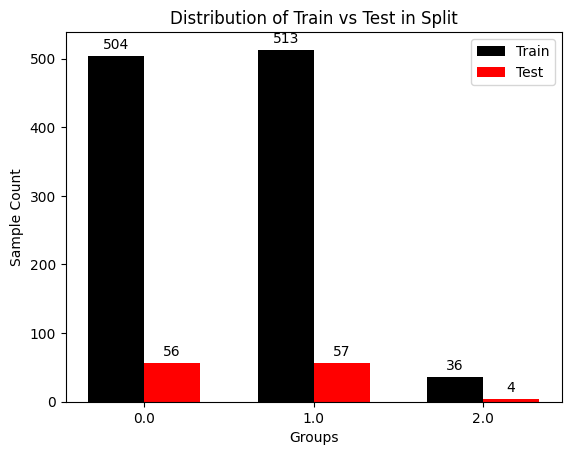



> Fold 1


2025-10-21 14:37:20.481456: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-21 14:37:20.481578: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-21 14:37:20.481607: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-21 14:37:20.815432: I external/l


Epoch 258: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 420: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 500: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 580: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 660: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 740: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 820: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 900: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 980: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.


2025-10-21 14:42:27.318210: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-21 14:42:27.544551: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_384', 8 bytes spill stores, 8 bytes spill loads

2025-10-21 14:42:27.719761: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_384', 8 bytes spill stores, 8 bytes spill loads

2025-10-21 14:42:29.704240: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does

loss: 18.482601165771484
compile_metrics: 18.97965431213379


2025-10-21 14:42:33.716642: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-21 14:42:34.062068: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_372', 8 bytes spill stores, 8 bytes spill loads



*********** Benchmark results ***********

R2    (Train/Test) = 0.992 / 0.752
RMSE  (Train/Test) = 5.338 / 27.795
Huber (Train/Test) = 3.414 / 18.483
Train: rmse (mean of 1 models)= 5.338090826130506 
Test: rmse (mean of 1 models)= 27.79517744353303
Train: r2 (mean of 1 models)= 0.9918510919779604 
Test: r2 (mean of 1 models)= 0.7515713085590963
Train: huber (mean of 1 models)= 3.413994789123535 
Test: huber (mean of 1 models)= 18.48259735107422


In [84]:
# 3173, 6113
# Anabell: 2 Folds & 100 epochs
# Berta: 2 Folds & 500 epochs
seeds = [3173] #,6113]
all_mwds = []

for seed in seeds:
    print(f"Using seed {seed}")
    (bestMwd, all_mwds_of_run) = evaluations_of_models(features, labels, DenseN=351, DropoutR=0.0, C1_K=55, C1_S=45, C2_K=43, C2_S=36, C3_K=63, C3_S=1, seed=seed, name="Norbert", epochs=1000, years_in_group=100, validation_portion=0.1)
    all_mwds.extend(all_mwds_of_run)

In [85]:
def plot_model_performance(mwd: ModelWithData):
    # undo log transformation for better interpretability
    x_train_label = recalculate_year(mwd.train_label)
    x_test_label = recalculate_year(mwd.test_label)
    y_train_predicted = recalculate_year(mwd.train_predicted)
    y_test_predicted = recalculate_year(mwd.test_predicted)
    
    # Create an array of x-values ranging from the minimum to maximum of the data
    x_values = np.linspace(min(min(x_train_label), min(x_test_label)), max(max(x_train_label), max(x_test_label)), 100)

    # Plot the line of equality (y=x)
    plt.plot(x_values, x_values, color='blue', linestyle='--', label='Y = X line')

    # Scatter plot for predicted values
    plt.scatter(x_train_label, y_train_predicted, c='k', label='Train Labels')
    plt.scatter(x_test_label, y_test_predicted, c='r', label='Test Labels')

    # Labels, legend, and title
    plt.xlabel('True Labels')
    plt.ylabel('Predicted Labels')
    plt.legend()
    plt.title('Scatter Plot of True vs Predicted Labels with Line of Equality')

    # Show the plot
    plt.show()

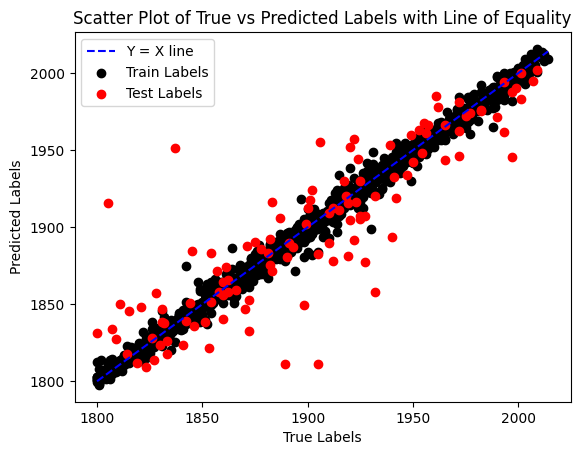

In [86]:
for mdw in all_mwds:
    plot_model_performance(mdw)

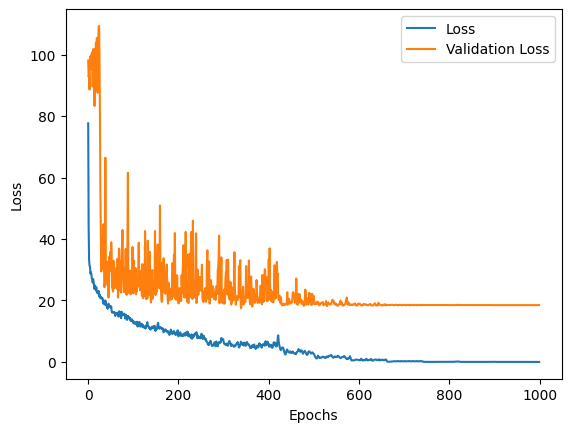

In [87]:
plt.plot(bestMwd.history.history['loss'], label='Loss')
plt.plot(bestMwd.history.history['val_loss'], label='Validation Loss')

#plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
# ax2 = plt.gca().twinx()
# ax2.plot(bestMwd.history.history['learning_rate'], color='r')
# ax2.set_ylabel('Learning Rate',color='r')

Eval_of_model = plt.legend()

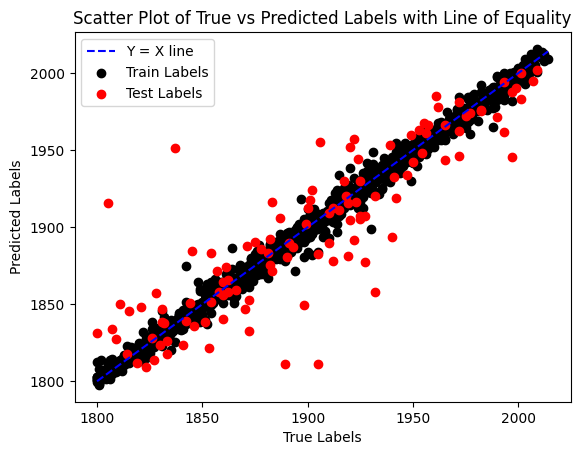

In [88]:
# undo log transformation for better interpretability
x_train_label = recalculate_year(bestMwd.train_label)
x_test_label = recalculate_year(bestMwd.test_label)
y_train_predicted = recalculate_year(bestMwd.train_predicted)
y_test_predicted = recalculate_year(bestMwd.test_predicted)

# Create an array of x-values ranging from the minimum to maximum of the data
x_values = np.linspace(min(labels), max(labels), 100)

# Plot the line of equality (y=x)
plt.plot(x_values, x_values, color='blue', linestyle='--', label='Y = X line')

# Scatter plot for predicted values
plt.scatter(x_train_label, y_train_predicted, c='k', label='Train Labels')
plt.scatter(x_test_label, y_test_predicted, c='r', label='Test Labels')

# Labels, legend, and title
plt.xlabel('True Labels')
plt.ylabel('Predicted Labels')
plt.legend()
plt.title('Scatter Plot of True vs Predicted Labels with Line of Equality')

# Show the plot
plt.show()

## Save the model

In [89]:
bestMwd.model.save('dps1200sub_model.keras')

# Check if working

In [90]:
dps1200sub_model = tf.keras.models.load_model('dps1200sub_model.keras')

# Show the model architecture
dps1200sub_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 1,084,804 (4.14 MB)

# Evaluation of the restored model

In [91]:
evaluation_results = dps1200sub_model.evaluate(features, labels, verbose=0)
evaluation_labels = dps1200sub_model.metrics_names

for j in range(len(evaluation_results)):
    print(f'{evaluation_labels[j]}: {evaluation_results[j]}')


loss: 1800.291015625
compile_metrics: 1800.791015625


In [92]:
def error_metrices_restored_model(y_true, y_predicted):
    rmse_train = np.sqrt(mean_squared_error(y_true, y_predicted))
    R2_train= r2_score(y_true, y_predicted)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true, y_predicted).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    = {R2_train:.3f}")
    print(f"RMSE  = {rmse_train:.3f}")
    print(f"Huber = {hub_train:.3f}")

In [93]:
restored_pred = dps1200sub_model.predict(features, verbose=0)

# undo log transformation for better interpretability
restored_pred = recalculate_year(restored_pred)

In [94]:
error_metrices_restored_model(labels, restored_pred)

*********** Benchmark results ***********

R2    = 0.970
RMSE  = 10.144
Huber = 4.921
